In [26]:
from sklearn.linear_model import LinearRegression # regresión lineal
from sklearn.model_selection import train_test_split # importamos train_test_split para separar los datos
from sklearn.metrics import mean_squared_error # MSE
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.graphics.regressionplots import plot_leverage_resid2
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import extraccion.minioFunctions as mf

In [27]:
datos = mf.bajar_fichero(mf.crear_cliente(), "grupo3/cleaned/MI.parquet", "df")
print(datos)

Dataframe importado correctamente
            lat        lon    frp_mean       date  area_ha  elevacion_centro  \
0     43.219070  -6.655960  146.240000 2022-01-01    14.06       1012.903931   
1     36.876417   6.951603   65.496667 2022-01-04   124.22          4.535087   
2     45.191311  29.577375  101.732000 2022-01-05  2828.39          0.505476   
3     37.850200  22.449520   63.520000 2022-01-06    14.06        604.561340   
4     41.642350  -6.436230   72.490000 2022-01-15    14.06        721.111511   
...         ...        ...         ...        ...      ...               ...   
2021  36.576007   6.496840   72.216667 2025-10-25    47.21       1151.275146   
2022  41.636630  -0.753550   63.700000 2025-11-02    14.06        216.558746   
2023  36.705930   3.892600   56.440000 2025-11-13    14.06        724.765015   
2024  37.415130  32.673640  114.770000 2025-11-23    28.12       1048.098511   
2025  36.317120  29.370160   80.790000 2025-12-29    14.06          1.711459   

     

**Muestreo simple**

In [28]:
X = datos.drop(columns = ['frp_mean', 'date'])
y = datos['frp_mean']

#1. Dividimos en entrenamiento y 20% para validación y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle = False, test_size=0.2, random_state=42
)

print(X_train.shape, '\n')
print(X_test.shape, '\n')

print(y_train.shape, '\n')
print(y_test.shape, '\n')

(1620, 21) 

(406, 21) 

(1620,) 

(406,) 



In [29]:
#Escalamos los datos porque hay variables con escalas mucho mayores que otras
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns, 
    index=X_train.index
)

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# Ajustamos el modelo
modelo_simple2 = sm.OLS(y_train, X_train_sm).fit()
y_pred = modelo_simple2.predict(X_test_sm)

**ANÁLISIS**

**1.SUMMARY**

In [30]:
#Se hace summary (al igual que con R)
summary = modelo_simple2.summary().tables[1]
print(modelo_simple2.summary(), '\n')

                            OLS Regression Results                            
Dep. Variable:               frp_mean   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     5.098
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.09e-13
Time:                        20:42:08   Log-Likelihood:                -8294.5
No. Observations:                1620   AIC:                         1.663e+04
Df Residuals:                    1598   BIC:                         1.675e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 87.1030      1

In [37]:
#Para ver la tabla completa 
summary = pd.DataFrame(summary)
summary.to_csv("summary.csv")
summary = pd.read_csv("summary.csv")
print(summary)

    Unnamed: 0.1  Unnamed: 0                   0           1          2  \
0              0           0                 NaN        coef    std err   
1              1           1               const     87.1030      1.013   
2              2           2                 lat     -1.6287      1.758   
3              3           3                 lon      0.4483      1.156   
4              4           4             area_ha      3.4001      1.034   
5              5           5    elevacion_centro    -18.7137      9.447   
6              6           6              grados      9.1082     10.776   
7              7           7          porcentaje     -6.6904     10.545   
8              8           8           temp_mean      8.3387     17.043   
9              9           9            temp_max     -0.3054      9.553   
10            10          10            temp_min     -9.2685      8.867   
11            11          11       humidity_mean      0.2402      1.920   
12            12         

Se observa que tan solo 3 variables son realmente significativas en el modelo. Estas son area_ha, elevacion_centro y pressure_mean. 
Tenemos un valor de R^2 = 0.063, lo que indica que el modelo que incluye todas las variables representa tan solo un 6.3% la variable objetivo.

Valores tan altos de std error nos llevan a concluir, como en análisis previos de la anterior fase, la existencia de variables altamente correlacionadas, así como la posible existencia de multicolinealidad.

Procedemos a llevar a cabo un estudio de residuos y, tras ello, de multicolinealidad para plantear posibles soluciones.

**2.RESIDUOS VS LEVERAGE**

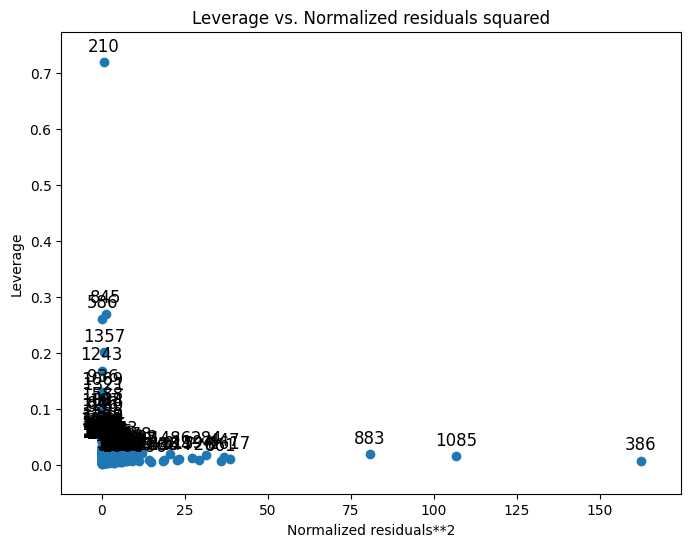

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
fig = plot_leverage_resid2(modelo_simple2, ax=ax)

Se observan valores extremadamente altos de residuos, lo que indica que una gran parte de los datos no son bien predichos por el modelo. El más alto es la observación 1355 con un valor residual de aproximadamente 11. 

El leverage no es extremadamente alto, destaca la observación 295 con un valor cercano a 0.7.

**3.QQPLOT**

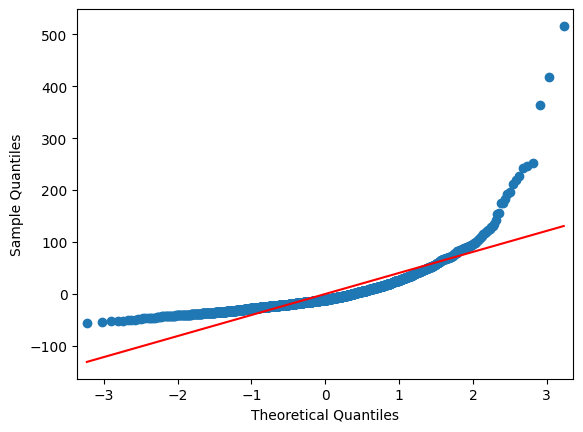

In [33]:
fig = sm.qqplot(modelo_simple2.resid, line = 's')
plt.show()

El gráfico QQplot muestra falta de normalidad en la distribución de los datos.

De la misma manera, rompe con el supuesto de linealidad.

Esta forma curva indica la necesidad de transformar la variable objetivo en escala logarítmica.

**4.DISTANCIA DE COOK**

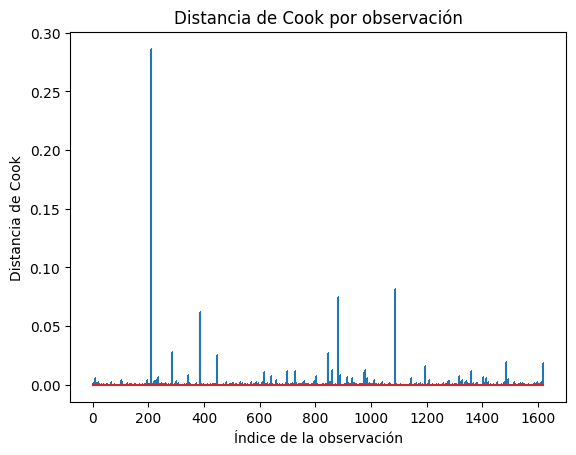

In [34]:
# 1. Obtener la influencia
influence = modelo_simple2.get_influence()

# 2. Extraer la distancia de Cook y los p-values asociados
(cooks, p_values) = influence.cooks_distance

# 3. Graficar
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.title("Distancia de Cook por observación")
plt.xlabel("Índice de la observación")
plt.ylabel("Distancia de Cook")
plt.show()

Las distancias de Cook son cercanas a 0. Destaca una elevada con un valor aproximado a 0.3. Posiblemente este dato sea el que tiene, a su vez, un alto leverage. Por lo que convendría considerarlo no solo como dato atípico, sino como una observación altamente influyente en el modelo, considerando eliminarla.

**6.MULTICOLINEALIDAD**

In [35]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i) 
                   for i in range(X_train_sm.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

              Variable         VIF
7            temp_mean  283.069759
5               grados  113.170045
6           porcentaje  108.362554
8             temp_max   88.930186
4     elevacion_centro   86.970524
14       pressure_mean   85.119714
9             temp_min   76.627085
17  evapotranspiration   22.512414
16           radiation   12.325800
18    sunshine_seconds    7.564822
12      wind_speed_max    6.509085
19                NDVI    5.998564
20                NDWI    5.751787
13      wind_gusts_max    5.599455
10       humidity_mean    3.594325
1                  lat    3.010411
15         cloud_cover    1.712107
2                  lon    1.301620
21            dist_civ    1.264931
11       precipitation    1.139906
3              area_ha    1.042857
0                const    1.000000


Todas las variables que tienen un VIF mayor que 10 indican necesariamente la existencia de multicolinealidad con otras. El claro ejemplo son las variables de temperatura, todas correlacionadas entre sí como veíamos en el análisis previo a esta fase.

Conviene llevar a cabo un proceso de selección de variables. 

**COMPROBACIÓN DE HIPÓTESIS**

In [36]:
estadistico, p_valor = stats.shapiro(modelo_simple2.resid)
print(f"P-valor Shapiro-Wilk: {p_valor}")

prueba_bp = sms.het_breuschpagan(modelo_simple2.resid, X_train_sm)
print(f"P-valor Breusch-Pagan: {prueba_bp[1]}")

P-valor Shapiro-Wilk: 4.3408936303383475e-46
P-valor Breusch-Pagan: 0.6538720782341361


Un valor tan extremadamente bajo como es el obtenido en el test de Shapiro-Wilk nos lleva a concluir que los datos no cumplen con la hipótesis de normalidad. 

Por otro lado, el test de Breusch-Pagan indica que hay heterocedasticidad.